## Birds and Drones

> dataset: https://www.kaggle.com/datasets/stealthknight/bird-vs-drone

In [1]:
! pip install -q kaggle

In [2]:
 from google.colab import files

 files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"aliakbar138118","key":"e0d6ee58e94f04da2990ade3816d21e2"}'}

In [3]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download stealthknight/bird-vs-drone

Dataset URL: https://www.kaggle.com/datasets/stealthknight/bird-vs-drone
License(s): MIT


In [5]:
!unzip /content/bird-vs-drone.zip

Streaming output truncated to the last 5000 lines.
  inflating: Dataset/train/labels/DTR (8630).txt  
  inflating: Dataset/train/labels/DTR (8631).txt  
  inflating: Dataset/train/labels/DTR (8632).txt  
  inflating: Dataset/train/labels/DTR (8633).txt  
  inflating: Dataset/train/labels/DTR (8634).txt  
  inflating: Dataset/train/labels/DTR (8635).txt  
  inflating: Dataset/train/labels/DTR (8636).txt  
  inflating: Dataset/train/labels/DTR (8637).txt  
  inflating: Dataset/train/labels/DTR (8638).txt  
  inflating: Dataset/train/labels/DTR (8639).txt  
  inflating: Dataset/train/labels/DTR (864).txt  
  inflating: Dataset/train/labels/DTR (8640).txt  
  inflating: Dataset/train/labels/DTR (8641).txt  
  inflating: Dataset/train/labels/DTR (8642).txt  
  inflating: Dataset/train/labels/DTR (8643).txt  
  inflating: Dataset/train/labels/DTR (8644).txt  
  inflating: Dataset/train/labels/DTR (8645).txt  
  inflating: Dataset/train/labels/DTR (8646).txt  
  inflating: Dataset/train/label

In [6]:
from tensorflow.keras.utils import image_dataset_from_directory
import matplotlib.pyplot as plt

In [7]:
train = image_dataset_from_directory('Dataset/train')
valid = image_dataset_from_directory('Dataset/valid')
test = image_dataset_from_directory('Dataset/test')

Found 18323 files belonging to 2 classes.
Found 1740 files belonging to 2 classes.
Found 889 files belonging to 2 classes.


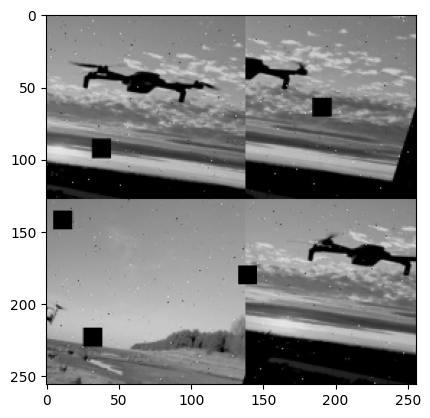

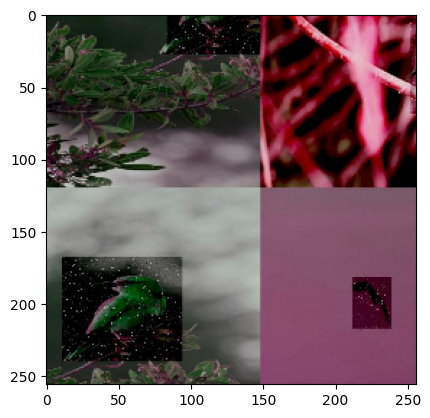

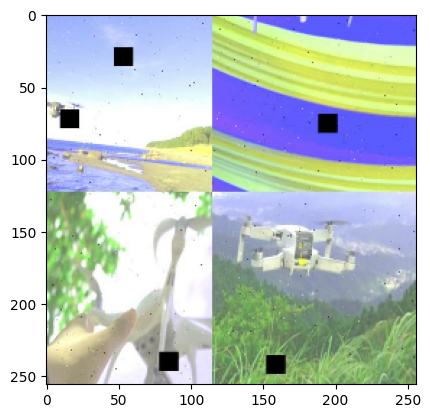

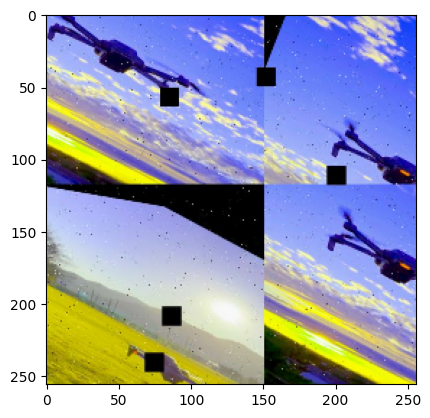

In [8]:
for image, label in train.take(1):
  plt.imshow(image[0].numpy().astype('uint8'))
  plt.show()
  plt.imshow(image[5].numpy().astype('uint8'))
  plt.show()
  plt.imshow(image[10].numpy().astype('uint8'))
  plt.show()
  plt.imshow(image[15].numpy().astype('uint8'))
  plt.show()

## Modeling

In [9]:
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

In [10]:
base_model = VGG16(weights='imagenet', input_shape=(256, 256, 3), include_top=False, pooling='avg')

model = Sequential()
model.add(base_model)
model.add(Dropout(.2))
model.add(Dense(1, activation='sigmoid'))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [12]:
model.fit(train, validation_data=valid, epochs=10)

Epoch 1/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 449s 697ms/step - accuracy: 0.9906 - loss: 0.0551 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 401s 602ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 382s 601ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 382s 601ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 382s 601ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 382s 601ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 373s 586ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/10
573/573 ━━━━━

### Fine Tunning

In [13]:
base_model = VGG16(weights='imagenet', input_shape=(256, 256, 3), include_top=False, pooling='avg')

base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 256, 256, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 256, 256, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 128, 128, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 128, 128, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 128, 128, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 64, 64, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 64, 64, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 64, 64, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 64, 64, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 32, 32, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 32, 32, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 32, 32, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 32, 32, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 16, 16, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 8, 8, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
base_model.trainable = False
for layer in base_model.layers[-4:]:
  layer.trainble = True

In [19]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 256, 256, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 256, 256, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 128, 128, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 128, 128, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 128, 128, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 64, 64, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 64, 64, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 64, 64, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 64, 64, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 32, 32, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 32, 32, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 32, 32, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 32, 32, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 16, 16, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 16, 16, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 8, 8, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [20]:
model = Sequential()
model.add(base_model)
model.add(Dropout(.2))
model.add(Dense(1, activation='sigmoid'))

In [24]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [25]:
model.fit(train, validation_data=valid, epochs=4)

Epoch 1/4
573/573 ━━━━━━━━━━━━━━━━━━━━ 161s 276ms/step - accuracy: 0.9818 - loss: 0.0672 - val_accuracy: 1.0000 - val_loss: 0.0015
Epoch 2/4
573/573 ━━━━━━━━━━━━━━━━━━━━ 146s 254ms/step - accuracy: 1.0000 - loss: 2.0828e-04 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 3/4
573/573 ━━━━━━━━━━━━━━━━━━━━ 146s 254ms/step - accuracy: 1.0000 - loss: 1.1334e-04 - val_accuracy: 1.0000 - val_loss: 7.8416e-04
Epoch 4/4
573/573 ━━━━━━━━━━━━━━━━━━━━ 202s 255ms/step - accuracy: 1.0000 - loss: 7.7396e-05 - val_accuracy: 1.0000 - val_loss: 5.9915e-04


In [27]:
model.evaluate(test)

28/28 ━━━━━━━━━━━━━━━━━━━━ 19s 698ms/step - accuracy: 1.0000 - loss: 4.6343e-04


[0.00032922058016993105, 1.0]

In [37]:
for image, label in test.take(1):
  print(model.predict(tf.expand_dims(image[0], axis=0)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
[[2.0619368e-06]]
